# Лабораторная работа 1

## Инкин Артем Игоревич, 6401-010302D
## Вариант 3

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html

In [2]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



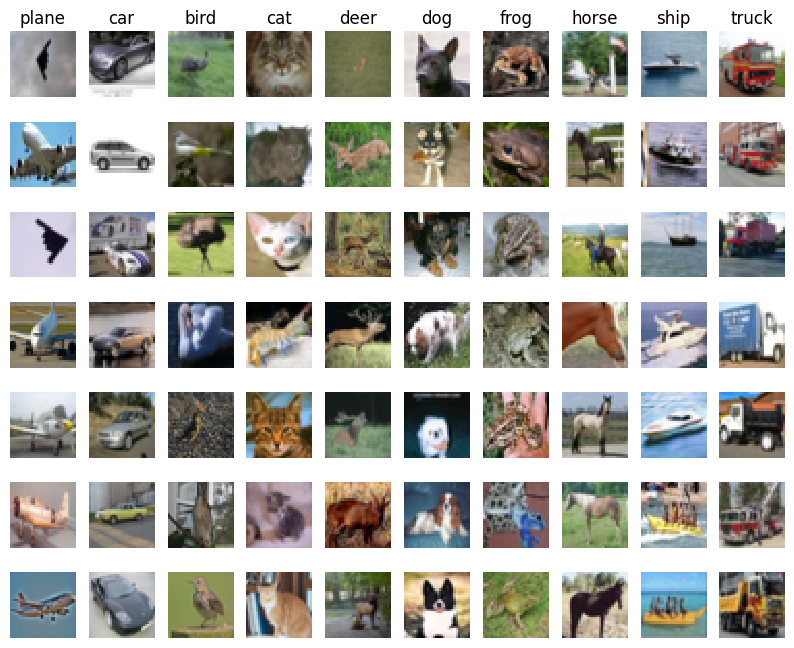

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
num_training = 5000
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

num_test = 500
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
print(X_train.shape, X_test.shape)

(5000, 3072) (500, 3072)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
dists = classifier.compute_distances_no_loops(X_test)
print(dists.shape)
y_test_pred = classifier.predict_labels(dists, k=1)
print(y_test_pred[:20])

(500, 5000)
[4. 9. 8. 8. 4. 4. 3. 2. 5. 8. 2. 8. 5. 7. 2. 2. 5. 3. 1. 4.]


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


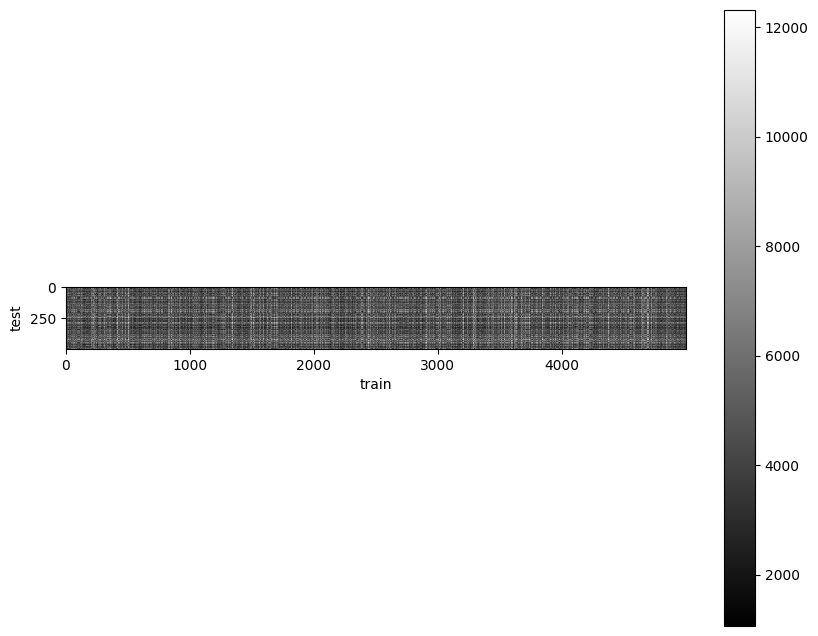

In [7]:
plt.imshow(dists, interpolation='none')
plt.xlabel('train')
plt.ylabel('test')
plt.colorbar()
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = num_correct / num_test
print('Получили %d / %d верных, точность: %f' % (num_correct, num_test, accuracy))

Получили 137 / 500 верных, точность: 0.274000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

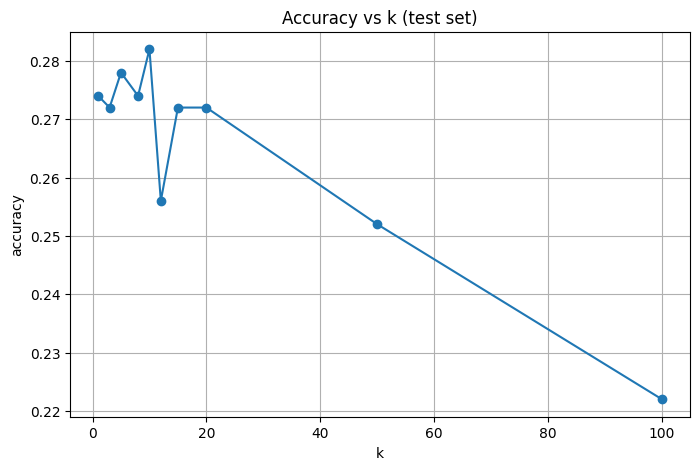

In [9]:
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]
accuracies = []
for k in k_choices:
    y_pred = classifier.predict_labels(dists, k=k)
    accuracies.append(np.mean(y_pred == y_test))

plt.figure(figsize=(8,5))
plt.plot(k_choices, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('Accuracy vs k (test set)')
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [10]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20, 50, 100]

X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {}
for k in k_choices:
    k_to_accuracies[k] = []
    for f in range(num_folds):
        X_tr = np.concatenate(X_train_folds[:f] + X_train_folds[f+1:])
        y_tr = np.concatenate(y_train_folds[:f] + y_train_folds[f+1:])
        X_val = X_train_folds[f]
        y_val = y_train_folds[f]
        
        classifier.train(X_tr, y_tr)
        y_val_pred = classifier.predict(X_val, k=k)
        k_to_accuracies[k].append(np.mean(y_val_pred == y_val))
        
for k in sorted(k_to_accuracies):
    mean_acc = np.mean(k_to_accuracies[k])
    std_acc = np.std(k_to_accuracies[k])
    print('k = %d: mean = %.4f, std = %.4f' % (k, mean_acc, std_acc))

best_k = max(k_to_accuracies, key=lambda k: np.mean(k_to_accuracies[k]))
print('\nЛучшее k:', best_k, 'со средней точностью', np.mean(k_to_accuracies[best_k]))

k = 1: mean = 0.2656, std = 0.0069
k = 3: mean = 0.2496, std = 0.0099
k = 5: mean = 0.2732, std = 0.0151
k = 8: mean = 0.2760, std = 0.0094
k = 10: mean = 0.2802, std = 0.0101
k = 12: mean = 0.2794, std = 0.0113
k = 15: mean = 0.2750, std = 0.0125
k = 20: mean = 0.2790, std = 0.0050
k = 50: mean = 0.2744, std = 0.0079
k = 100: mean = 0.2616, std = 0.0052

Лучшее k: 10 со средней точностью 0.2802



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [11]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)

num_correct = np.sum(y_test_pred == y_test)
accuracy = num_correct / num_test
print('Получили %d / %d верных, точность: %f' % (num_correct, num_test, accuracy))

Получили 141 / 500 верных, точность: 0.282000


1.11 Сделайте выводы по результатам 1 части задания.

Для скорости брал подвыборку 5000 картинок в обучающей выборке и 500 в тестовой.

При k=1 точность на тесте получилась 27.4% (137 правильных из 500). Это лучше случайного угадывания (10% для 10 классов), но всё равно низко. Видимо, расстояние между пикселями плохо отражает то, насколько картинки похожи по смыслу - две машины с разным фоном могут оказаться дальше друг от друга, чем машина и грузовик на одинаковом фоне.

Кросс-валидация с 5 фолдами показала, что лучшее k=10 со средней точностью 28.02%. После переобучения на полной выборке с этим k точность на тесте составила 28.2% (141/500) - чуть лучше, чем при k=1.

По графику видно, что при k=1 классификатор слишком чувствителен к отдельным шумным соседям, при k=3 проседает, потом точность растёт и выходит на плато на k=8-12, а после k=20 начинает падать - большие k усредняют слишком много разных меток подряд.

Главные минусы метода - нужно хранить всю обучающую выборку и считать расстояние до каждого её элемента при предсказании, плюс точность на картинках низкая. Для классификации изображений kNN не подходит.

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [12]:
cifar10_dir = 'scripts/datasets/cifar-10-batches-py'
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

mask = list(range(num_training, num_training + num_validation))
X_val = X_train[mask]
y_val = y_train[mask]

mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print('Размер обучающей выборки:', X_train.shape)
print('Размер валидационной выборки:', X_val.shape)
print('Размер тестовой выборки:', X_test.shape)
print('Размер dev-выборки:', X_dev.shape)

Размер обучающей выборки: (49000, 3072)
Размер валидационной выборки: (1000, 3072)
Размер тестовой выборки: (1000, 3072)
Размер dev-выборки: (500, 3072)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [13]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]
(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


3.4 Реализуйте функции в classifiers/softmax.py




In [14]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.389168
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [15]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -0.010369 analytic: -0.010369, relative error: 3.479803e-06
numerical: 0.388372 analytic: 0.388372, relative error: 4.003874e-09
numerical: 0.391509 analytic: 0.391509, relative error: 1.850550e-07
numerical: 2.690255 analytic: 2.690254, relative error: 1.074781e-08
numerical: -0.357861 analytic: -0.357861, relative error: 1.921954e-08
numerical: 1.849789 analytic: 1.849789, relative error: 7.701298e-09
numerical: -1.386384 analytic: -1.386384, relative error: 1.041400e-09
numerical: 1.524103 analytic: 1.524103, relative error: 3.182222e-08
numerical: 1.531403 analytic: 1.531403, relative error: 8.311408e-09
numerical: 2.065714 analytic: 2.065714, relative error: 1.524100e-08
numerical: -1.420947 analytic: -1.420947, relative error: 6.913309e-09
numerical: -0.154498 analytic: -0.154498, relative error: 2.549746e-07
numerical: 1.623663 analytic: 1.623662, relative error: 3.953201e-08
numerical: 0.952749 analytic: 0.952749, relative error: 1.566797e-08
numerical: -0.471554 ana

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [16]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.389168e+00 computed in 0.046512s
vectorized loss: 2.389168e+00 computed in 0.003994s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

In [17]:
from scripts.classifiers import Softmax

softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                        num_iters=1500, verbose=True)
toc = time.time()
print('Обучение заняло %fs' % (toc - tic))

y_train_pred = softmax.predict(X_train)
print('Точность на обучающей: %f' % np.mean(y_train == y_train_pred))
y_val_pred = softmax.predict(X_val)
print('Точность на валидации: %f' % np.mean(y_val == y_val_pred))
y_test_pred = softmax.predict(X_test)
print('Точность на тесте: %f' % np.mean(y_test == y_test_pred))

iteration 0 / 1500: loss 782.177287
iteration 100 / 1500: loss 286.963352
iteration 200 / 1500: loss 106.426322
iteration 300 / 1500: loss 40.215407
iteration 400 / 1500: loss 16.017202
iteration 500 / 1500: loss 7.137270
iteration 600 / 1500: loss 3.983309
iteration 700 / 1500: loss 2.747300
iteration 800 / 1500: loss 2.296133
iteration 900 / 1500: loss 2.185832
iteration 1000 / 1500: loss 2.130168
iteration 1100 / 1500: loss 2.067919
iteration 1200 / 1500: loss 2.139193
iteration 1300 / 1500: loss 2.110440
iteration 1400 / 1500: loss 2.105494
Обучение заняло 4.473030s
Точность на обучающей: 0.328939
Точность на валидации: 0.339000
Точность на тесте: 0.349000


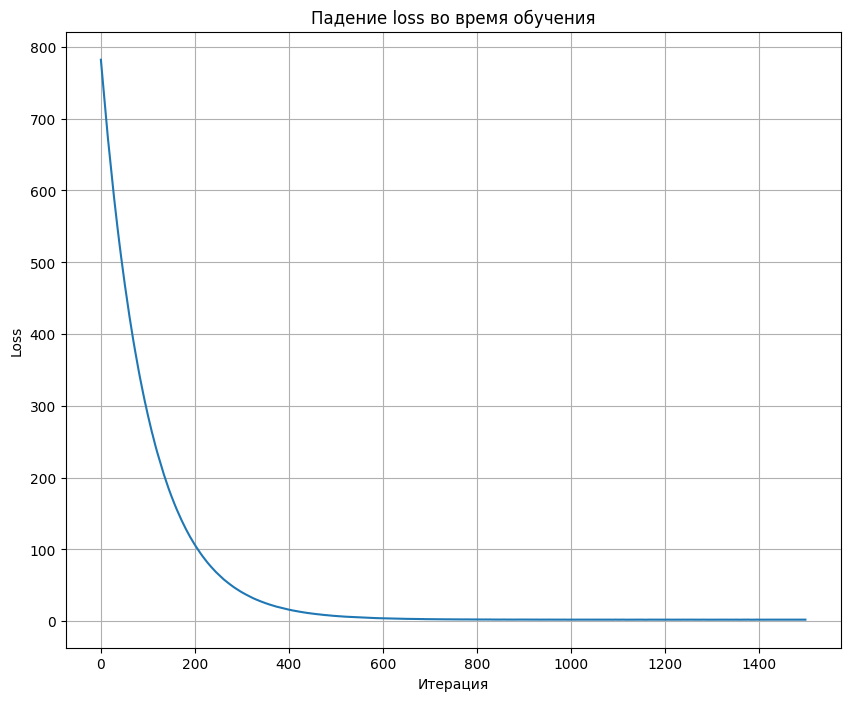

In [18]:
plt.plot(loss_hist)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Падение loss во время обучения')
plt.grid(True)
plt.show()

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [19]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

results = {}
best_val = -1
best_softmax = None

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(X_train, y_train, learning_rate=lr, reg=reg,
                      num_iters=1500, verbose=False)
        train_acc = np.mean(y_train == softmax.predict(X_train))
        val_acc = np.mean(y_val == softmax.predict(X_val))
        results[(lr, reg)] = (train_acc, val_acc)
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax

for lr, reg in sorted(results):
    train_acc, val_acc = results[(lr, reg)]
    print('lr %e reg %e: train %f, val %f' % (lr, reg, train_acc, val_acc))

print('Лучшая точность на валидации: %f' % best_val)

y_test_pred = best_softmax.predict(X_test)
test_acc = np.mean(y_test == y_test_pred)
print('Точность на тесте лучшего классификатора: %f' % test_acc)

c:\Users\artem\OneDrive\Рабочий стол\8 семестр\Технологии ИИ\Лабы Часть 2\Lab1-2\scripts\classifiers\softmax.py:84: RuntimeWarning: divide by zero encountered in log
  loss = -np.sum(np.log(probs[np.arange(num_train), y])) / num_train
c:\Users\artem\OneDrive\Рабочий стол\8 семестр\Технологии ИИ\Лабы Часть 2\Lab1-2\scripts\classifiers\softmax.py:85: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
c:\Users\artem\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\artem\OneDrive\Рабочий стол\8 семестр\Технологии ИИ\Лабы Часть 2\Lab1-2\scripts\classifiers\softmax.py:85: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
c:\Users\artem\OneDrive\Рабочий стол\8 семестр\Технологии ИИ\Лабы Часть 2\Lab1-2\scripts\classifiers\softmax.py:89: RuntimeWarning: overflow encountered in mu

lr 1.000000e-07 reg 2.500000e+04: train 0.331143, val 0.344000
lr 1.000000e-07 reg 5.000000e+04: train 0.307224, val 0.317000
lr 5.000000e-05 reg 2.500000e+04: train 0.090898, val 0.105000
lr 5.000000e-05 reg 5.000000e+04: train 0.100265, val 0.087000
Лучшая точность на валидации: 0.344000
Точность на тесте лучшего классификатора: 0.346000


3.10 Сделайте выводы по третьей части задания

Использовалась полная обучающая выборка (49000 картинок), валидационная (1000), тестовая (1000) и dev-выборка из 500 случайных примеров для проверки реализации loss-функции и градиента.

При обучении с lr=1e-7 и reg=2.5e4 за 1500 итераций loss упал с 769 до примерно 2.1, что говорит о нормальной сходимости градиентного спуска. Точность получилась 32.9% на обучающей, 33.9% на валидационной и 34.9% на тестовой выборках.

Перебор по сетке гиперпараметров показал, что при больших значениях скорости обучения (lr=5e-5) метод расходится - выскакивают предупреждения про переполнение. Шаг градиента слишком большой и веса улетают в бесконечность. Лучшая комбинация из проверенных - lr=1e-7, reg=2.5e4, на тесте она дала 34.6% точности.

По сравнению с kNN из первой части (28.2% на тесте) softmax работает заметно лучше. При этом обучение занимает несколько секунд, а предсказание - одно матричное умножение, тогда как kNN на этапе предсказания должен считать расстояния до всей обучающей выборки. 

То есть softmax быстрее и точнее, хотя оба метода всё равно слабоваты для задачи классификации картинок - 34.6% это не то чтобы много для 10 классов.